In [1]:
# import classy module
from classy import Class

In [2]:
# create instance of the class "Class"
LambdaCDM = Class()
# pass input parameters
# LambdaCDM.set({'omega_b':0.0223828,'omega_cdm':0.1201075,'h':0.67810,'A_s':2.100549e-09,'n_s':0.9660499,'tau_reio':0.05430842})
LambdaCDM.set({'omega_b':0.02237,'omega_cdm':0.1200,'h':0.6736,'A_s':2.0830e-9,'n_s':0.9649,'tau_reio':0.0568, 'k_pivot': 0.05, 'N_ur':3.046, 'T_cmb': 2.7255})
LambdaCDM.set({'output':'mPk','lensing':'no','P_k_max_1/Mpc':3.0, 'z_max_pk': 1.0})

# run class
LambdaCDM.compute()

# get reduced Hubble for conversions to 1/Mpc
h = LambdaCDM.h()
print(h)

0.6736


In [3]:
# uncomment to get plots displayed in notebook
%matplotlib inline
import matplotlib.pyplot as plt
from math import pi
from matplotlib import rc
from matplotlib import rcParams
from matplotlib.gridspec import GridSpec
import numpy as np
import pandas as pd
from plotting_utils import plot_segments

# Enable LaTeX rendering
rcParams['figure.dpi'] = 120

rc('text', usetex=True)
rc('font', family='serif', size=15)

rcParams.update({
    'font.size': 15,
    'axes.titlesize': 15,
    'axes.labelsize': 15,
    'xtick.labelsize': 15,
    'ytick.labelsize': 15,
    'legend.fontsize': 15,
})

In [4]:
dir = "/Users/fynn/Desktop/Uni/Master/Masters-thesis/02 external_codes/python-integer-powers-master"
# Read the file content
#with open(dir+'/pk_fid.dat', 'r') as file:
#    data = file.readlines()  # This gives you a list of lines



# Now split each line into a list of values (splitting by spaces in your case)
#data = np.loadtxt(dir+'/pk_fid.dat')
#kk = data[:, 0]*h
#Pk = data[:, 1]/h**3

k_size = 500
z_size = 1
mu_size= 1

k_min = 1e-3*h
k_max = 1.*h

k = np.logspace(np.log10(k_min),np.log10(k_max), k_size)
k_input = k.reshape((k_size, z_size, mu_size)) # need to reshape to also habe z and mu dependence
z = np.linspace(0, 1, z_size)




Pk = LambdaCDM.get_pk_lin(k_input, z, k_size, z_size, mu_size)[:,0,0]

#np.savetxt("P_lin.csv", Pk, delimiter=",")
#np.savetxt("k_arr.csv", k, delimiter=",")




In [5]:
c_alpha = LambdaCDM.get_pfit_coeffs(k_size, k_min, k_max, z[0])


# Fitting the linear power spectrum

### $P_{fit}(k^2) = \sum_{n=0}^{N-1} \alpha_n f_n(k^2)$ 

### goal: determine $\alpha_n$

where $\alpha_n$ are cosmology dependent coefficients and $f_n$ are cosmology independent fitting functions


### $f_n(k^2, k^2_{\text{peak},n}, k^2_{\text{UV},n}, i_n, j_n) = \left( \frac{k^2}{k^2_0} \right)^{i_n}\  \left[ 1 + \frac{ \left(k^2-k^2_{\text{peak},n} \right)^2}{k^4_{\text{UV},n}} \right]^{-j_n}$

except for $n=0$

### $f_0(k^2) = \frac{1}{1 + \frac{k^2}{k^2_{\text{UV},0}}}$.


We use the following terms

$P_{fit}(k^2) = \frac{a_0}{1+ \frac{k^2}{k^2_{\text{UV},0}}} + \sum_{i=1}^3  a_i f(k^2, k^2_{\text{peak}, 1}, k^2_{\text{UV},1}, 0 , i)+ \sum_{i=0}^3  \left[ b_i f(k^2, k^2_{\text{peak}, 2}, k^2_{\text{UV}, 2}, 1 , i+1) + c_i f(k^2, k^2_{\text{peak}, 3}, k^2_{\text{UV}, 3}, 0 , i+2) + d_i f(k^2, k^2_{\text{peak}, 4}, k^2_{\text{UV}, 4}, 0 , i+1) \right]
$


which means:
 
$$
\begin{array}{|c|c|c|c|c|c|}
\hline
n & \alpha_n & k^2_{\text{peak},n} & k^2_{\text{UV},n} & i_n & j_n \\[5pt]
\hline
0 & a_0 & - & k^2_{\text{UV},0} & -  & - \\[5pt]
1 & a_1 & k^2_{\text{peak},1} & k^2_{\text{UV},1} & 0 & 1 \\[5pt]
2 & a_2 & k^2_{\text{peak},1} & k^2_{\text{UV},1} & 0 & 2  \\[5pt]
3 & a_3 & k^2_{\text{peak},1} & k^2_{\text{UV},1} & 0 & 3 \\[5pt]
4 & b_0 & k^2_{\text{peak},2} & k^2_{\text{UV},2} & 1 & 1 \\[5pt]
5 & b_1 & k^2_{\text{peak},2} & k^2_{\text{UV},2} & 1 & 2 \\[5pt]
6 & b_2 & k^2_{\text{peak},2} & k^2_{\text{UV},2} & 1 & 3 \\[5pt]
7 & b_3 & k^2_{\text{peak},2} & k^2_{\text{UV},2} & 1 & 4 \\[5pt]
8 & c_0 & k^2_{\text{peak},3} & k^2_{\text{UV},3} & 0 & 2 \\[5pt]
9 & c_1 & k^2_{\text{peak},3} & k^2_{\text{UV},3} & 0 & 3 \\[5pt]
10 & c_2 & k^2_{\text{peak},3} & k^2_{\text{UV},3} & 0 & 4 \\[5pt]
11 & c_3 & k^2_{\text{peak},3} & k^2_{\text{UV},3} & 0 & 5 \\[5pt]
12 & d_0 & k^2_{\text{peak},4} & k^2_{\text{UV},4} & 0 & 1 \\[5pt]
13 & d_1 & k^2_{\text{peak},4} & k^2_{\text{UV},4} & 0 & 2 \\[5pt]
14 & d_2 & k^2_{\text{peak},4} & k^2_{\text{UV},4} & 0 & 3 \\[5pt]
15 & d_3 & k^2_{\text{peak},4} & k^2_{\text{UV},4} & 0 & 4 \\
\hline
\end{array}
$$

with

* $k^2_{\text{peak},n} \in - \{ 3.4 \cdot 10^{-2},\ 1 \cdot 10^{-3},\ 7.6 \cdot 10^{-5},\  1.56 \cdot 10^{-5} \}\frac{h^2}{Mpc^2}$

* $k^2_{\text{UV},n} \in \{ 1 \cdot 10^{-4},\ 6.9 \cdot 10^{-2},\ 8.2 \cdot 10^{-3},\  1.3 \cdot 10^{-3},\ 1.35 \cdot 10^{-5} \}\frac{h^2}{Mpc^2}$

alpha_n [  -63361.89481398     4157.95731483    -9136.66782553    14043.62494933
    26695.42891119    13524.34721539   -10847.25526326   138058.6819478
   298704.78149139  -374119.09119922   135982.13637315    40854.79828213
   -45330.71822065  -228699.39646404  1080841.07826616 -1751794.74244336]
alpha_c [  -63361.89475141     4157.95730777    -9136.66777152    14043.62480406
    26695.42891478    13524.34783764   -10847.25695486   138058.68327668
   298704.7824509   -374119.09534436   135982.14233931    40854.79548372
   -45330.71858061  -228699.39465447  1080841.07374329 -1751794.73822462]


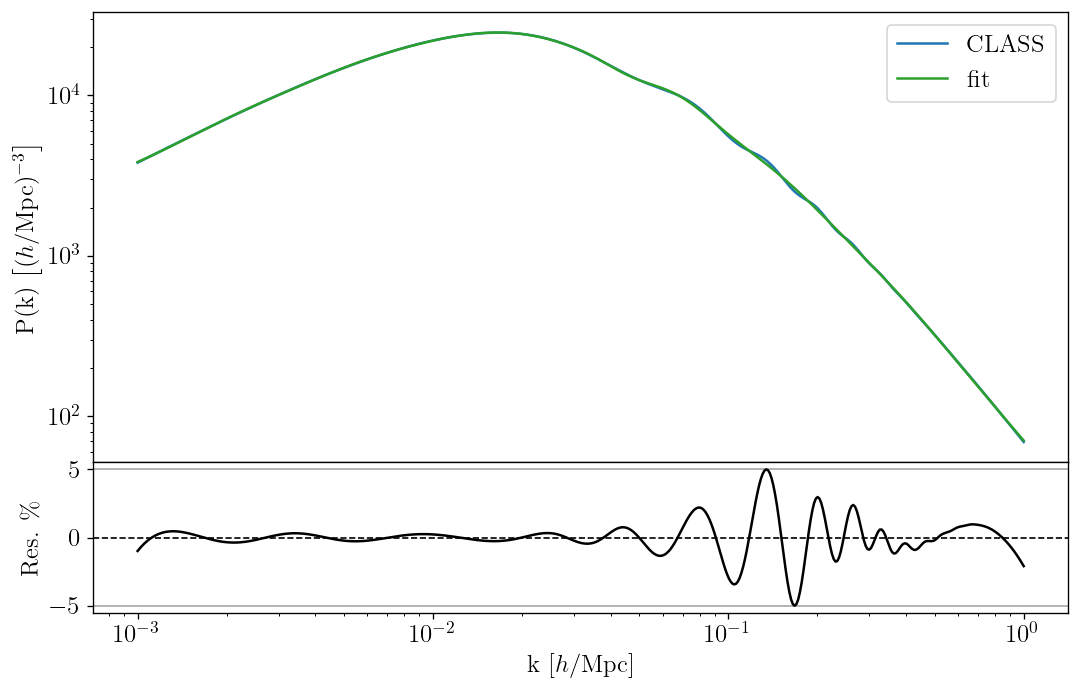

In [6]:
import scipy.optimize as opt

N = 16

k0 = h/20
k2_peak_n = np.array([0, -3.4e-2, -1e-3, -7.6e-5, -1.56e-5])*h**2
k2_UV_n = np.array([1e-4, 6.9e-2, 8.2e-3, 1.3e-3, 1.35e-5])*h**2 # original
i_n = np.array([0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0])
j_n = np.array([1, 1, 2, 3, 1, 2, 3, 4, 2, 3, 4, 5, 1, 2, 3, 4])
n = np.arange(0, 16)




def f_n(n, k2, k2_peak_n, k2_UV_n, i, j):
    arr = np.zeros(N)

    for idx, m in enumerate(n):
        if m==0:
            k2_UV = k2_UV_n[0]
            k2_peak = k2_peak_n[0]
            
        elif m>0 and m<=3:
            k2_UV = k2_UV_n[1]
            k2_peak = k2_peak_n[1]
            
        elif m>3 and m<=7:
            k2_UV = k2_UV_n[2]
            k2_peak = k2_peak_n[2]

        elif m>7 and m<=11:
            k2_UV = k2_UV_n[3]
            k2_peak = k2_peak_n[3]

        elif m>11 and m<=15:
            k2_UV = k2_UV_n[4]
            k2_peak = k2_peak_n[4]

        if m==0:
            arr[idx] = 1/(1+k2/k2_UV)
        else:
            # TODO: is this k0**2 or k2_UV -> paper seems incosistent, compare Eq. 2.2, and 2.8
            arr[idx] = (k2/k2_UV)**(i[idx]) * 1/(1 + (k2 - k2_peak)**2/k2_UV**2 )**(j[idx])
    return arr



# Use weighted least squares alpha = (X^T * W * X)^-1 * X^T * W * Plin
# W: weight matrix -> W=diag(1/err^2), where err = 1e-6*P_lin

err = Pk
W = np.diag(1./err**2)

#for i, y in enumerate(Pk):
#    print(f"Pk_{i} = {y}")


X = np.zeros((k_size, N))

for idx, k2 in enumerate(k**2):
    X[idx, :] = f_n(n, k2, k2_peak_n, k2_UV_n, i_n, j_n)

#for i in range(k_size):
#    for j in range(16):
#        print(f"X[{i}][{j}] = {X[i][j]}")








    

XT_X_inv = np.linalg.inv( np.dot(X.T, X) ) 
XT_W_X_inv = np.linalg.inv( np.dot( X.T , np.dot(W, X) ) ) 
A = np.dot( X.T , np.dot(W, X) )
A_inv = np.linalg.inv( A) 
M = np.dot( A_inv , np.dot(X.T,W) )
alpha_n = np.dot(M, Pk)
print("alpha_n", alpha_n)
print("alpha_c", c_alpha)


Pk_fit = np.dot(X, c_alpha)
residuals = 100*(1 - Pk_fit/Pk)

fig = plt.figure(figsize=(9.25, 6))
gs = GridSpec(2, 1, height_ratios=[3, 1], hspace=0)

# Main plot (data + fit)
ax1 = fig.add_subplot(gs[0])
ax1.plot(k/h, Pk*h**3, color="tab:blue", label="CLASS")
ax1.plot(k/h, Pk_fit*h**3, color="tab:green", label="fit")
ax1.set_ylabel(rf"P(k) $\left[(h/\mathrm{{Mpc}})^{{-3}}\right]$")
#ax1.set_xlim(1e-3, 0.5)
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.legend()
#ax1.grid()
#
# Residual plot (same x-axis)
ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax2.axhline(0, color='black', linestyle='--', linewidth=1)
ax2.axhline(-5, color='grey', alpha=0.7, linestyle='-', linewidth=1)
ax2.axhline(5, color='grey', alpha=0.7, linestyle='-', linewidth=1)
ax2.plot(k/h, residuals, color='black', label="Residuals")
#ax2.set_xlim(1e-3, 0.5)
#ax2.set_ylim(-7, 7)

ax2.set_xlabel(rf"k $\left[h/\mathrm{{Mpc}}\right]$")
ax2.set_ylabel(r"Res. $\%$")
ax2.set_xscale("log")
#ax2.grid()
plt.tight_layout()
plt.savefig("PS_fit.pdf")

# Expanding $f$:

### $f(k^2,k^2_{\text{peak}}, k^2_{\text{UV}}, i , j) = \sum_{n=1}^j k^{2(n-i)}_{\text{UV}} k^{2i} \left[ \frac{\kappa_n}{(k^2+M)^n} + \text{c.c.} \right]$
where $M = -k^2_{\text{peak}} + i k^2_{\text{UV}}$ and $\kappa_n$ are dimensionless coeffecients that need to be determined.


# Expanding $P_{fit}$:

### $P_{fit} = \sum_{n=0}^{N-1} \alpha_n f_n(k^2,k^2_{\text{peak},n}, k^2_{\text{UV},n}, i_n , j_n) \\[5pt] \qquad = \sum_{n=0}^{N-1} \sum_{m=1}^{j_n} \alpha_n k^{2(m-i_n)}_{\text{UV},n} k^{2i_n} \left[ \frac{\kappa_{j_n, m}}{(k^2+M_n)^m} + \text{c.c.} \right] \\[5pt] \qquad = \sum_{n=0}^{N-1} \sum_{m=1}^{j_n} X_{n, m}   \frac{k^{2i_n}}{(k^2+M_n)^m} + \text{c.c.} $


### $X_{n, m} = \alpha_n k^{2(m-i_n)}_{\text{UV},n} \kappa_{j_n, m}$

* $\alpha_n$: cosmology dependent

* $f_n$: cosmology independent


counter= 41


/Users/fynn/miniforge3/envs/class-env-1/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/fynn/miniforge3/envs/class-env-1/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


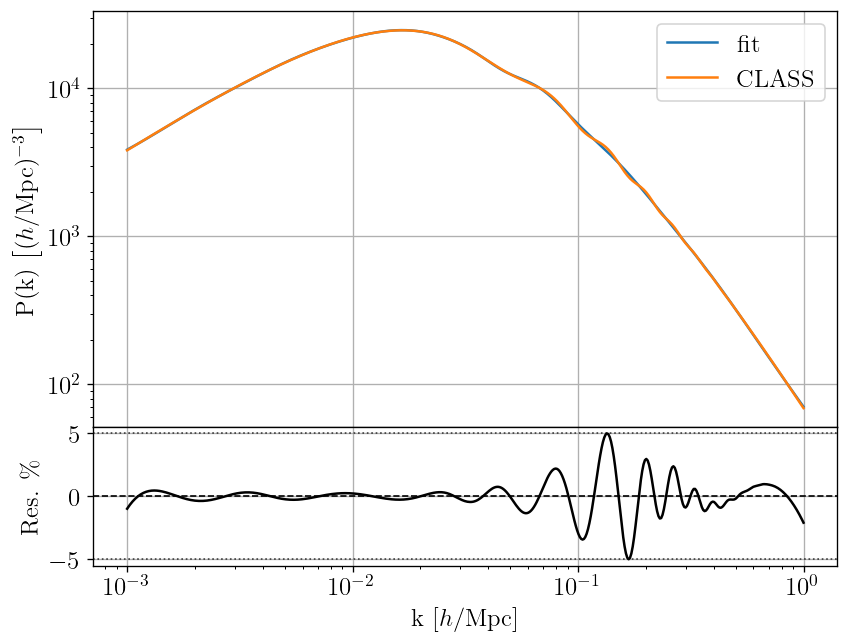

In [7]:
# Just as a reminder:
k2_peak_n = np.array([0, -3.4e-2, -1e-3, -7.6e-5, -1.56e-5])*h**2
k2_UV_n = np.array([1e-4, 6.9e-2, 8.2e-3, 1.3e-3, 1.35e-5])*h**2
i_n = np.array([0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0])
j_n = np.array([1, 1, 2, 3, 1, 2, 3, 4, 2, 3, 4, 5, 1, 2, 3, 4])


def M_n(n):
    if n==0:
        k2_UV = -1j*k2_UV_n[0]      # special case for f_0
        k2_peak = k2_peak_n[0]
    elif n>0 and n<=3:
        k2_UV = k2_UV_n[1]
        k2_peak = k2_peak_n[1]
    elif n>3 and n<=7:
        k2_UV = k2_UV_n[2]
        k2_peak = k2_peak_n[2]
    elif n>7 and n<=11:
        k2_UV = k2_UV_n[3]
        k2_peak = k2_peak_n[3]
    elif n>11 and n<=15:
        k2_UV = k2_UV_n[4]
        k2_peak = k2_peak_n[4]

    return -k2_peak + 1j*k2_UV

def kappa_j_m(j, m):
    if j==1:
        coeffs = np.array([1])
    elif j==2: 
        coeffs = np.array([2, 1])
    elif j==3: 
        coeffs = np.array([6, 3, 1])
    elif j==4:
        coeffs = np.array([20, 10, 4, 1])
    elif j==5:
        coeffs = np.array([70, 35, 15, 5, 1])

    kappa_1 = 1j/2

    return coeffs[m-1]*kappa_1**j * np.conj(kappa_1)**(j-m)

def X_n_m(n, m):
    j = j_n[n]
    i = i_n[n]
    alpha = alpha_n[n]

    if n==0:
        k2_UV = k2_UV_n[0]
    elif n>0 and n<=3:
        k2_UV = k2_UV_n[1]
    elif n>3 and n<=7:
        k2_UV = k2_UV_n[2]
    elif n>7 and n<=11:
        k2_UV = k2_UV_n[3]
    elif n>11 and n<=15:
        k2_UV = k2_UV_n[4]

    if n==0:
        kappa = 1/2
    else:
        kappa = kappa_j_m(j, m)
    
    return alpha * k2_UV**(m-i) * kappa


counter = 0
Pk_fit = 0.
for n in range(N):
    i = i_n[n]
    for m in range(1, j_n[n]+1):
        tmp = X_n_m(n, m) * k**(2*i)/ (k**2 + M_n(n))**m
        Pk_fit += tmp + np.conjugate(tmp)
        counter += 1

print(f"counter= {counter}")
counter = 0

fig = plt.figure(figsize=(8, 6))
gs = GridSpec(2, 1, height_ratios=[3, 1], hspace=0)

# Main plot (data + fit)
ax1 = fig.add_subplot(gs[0])
ax1.plot(k/h, Pk_fit*h**3, label="fit")
ax1.plot(k/h, Pk*h**3, label="CLASS")
ax1.set_ylabel(rf"P(k) $\left[(h/\mathrm{{Mpc}})^{{-3}}\right]$")
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.legend()
ax1.grid()

# Residual plot (same x-axis)
ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax2.axhline(0, color='black', linestyle='--', linewidth=1)
ax2.axhline(-5, color='black', alpha=0.7, linestyle=':', linewidth=1)
ax2.axhline(5, color='black', alpha=0.7, linestyle=':', linewidth=1)
ax2.plot(k/h, residuals, color='black', label="Residuals")
#ax2.set_ylim(-7, 7)
ax2.set_xlabel(rf"k $\left[h/\mathrm{{Mpc}}\right]$")
ax2.set_ylabel(r"Res. $\%$")
ax2.set_xscale("log")
ax2.grid()


# Validation of $\kappa_n$ and the expansion of $f$:

kappa_n:  [ 0.        +0.13671875j -0.13671875+0.j          0.        -0.1171875j
  0.078125  +0.j          0.        +0.03125j   ]


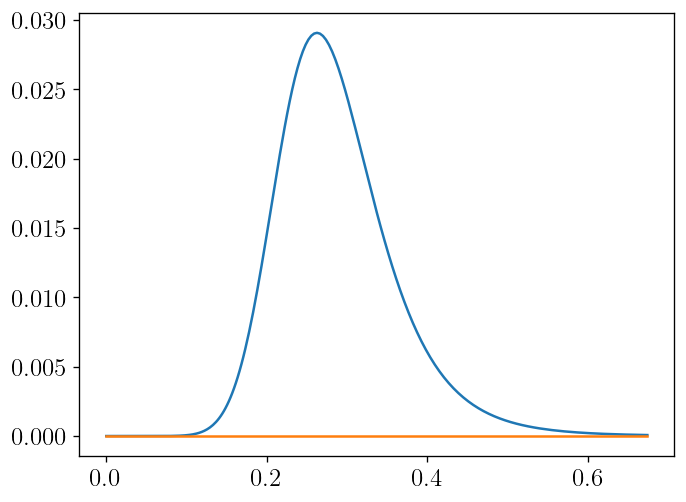

In [8]:
# kappa_n_ij:
kp = 1j/2
kappa_n_01_coeffs = np.array([1])
kappa_n_02_coeffs = np.array([2, 1])
kappa_n_03_coeffs = np.array([6, 3, 1])
kappa_n_04_coeffs = np.array([20, 10, 4, 1])
kappa_n_05_coeffs = np.array([70, 35, 15, 5, 1])

def kappa_j(j):
    if j==1:
        coeffs = np.array([1])
    elif j==2: 
        coeffs = np.array([2, 1])
    elif j==3: 
        coeffs = np.array([6, 3, 1])
    elif j==4:
        coeffs = np.array([20, 10, 4, 1])
    elif j==5:
        coeffs = np.array([70, 35, 15, 5, 1])


    kappa_1 = 1j/2
    arr = np.zeros(j, dtype=complex)
    for n, coeff in enumerate(coeffs):
        arr[n] = coeff*kappa_1**j * np.conj(kappa_1)**(j-n-1)
    return arr


def f_expand(k2, k2_UV, M, kappa, i, j):
    n = np.arange(1, j+1)
    arr = np.zeros(len(k2))
    for idx, k2_in in enumerate(k2):
        K = kappa/(k2_in + M)**n
        arr[idx] = k2_in**i * np.abs(np.sum( k2_UV**(n-i) * (K + np.conj(K)) ))
    return arr

def f(k2, k2_UV, M, i, j):
    k2_peak = 1j*k2_UV - M
    return (k2/k2_UV)**(i) * 1/(1 + (k2 - k2_peak)**2/k2_UV**2 )**(j)


k2_UV = 6.9e-2
k2_peak = -1e-3
M = -k2_peak + 1j*k2_UV

def diff(k2, k2_UV, M, i, j):
    return f(k2, k2_UV, M, i, j) - f_expand(k2, k2_UV, M, kappa_j(j), i, j)


i, j = 5, 5
print("kappa_n: ", kappa_j(j))

diff_f = diff(k**2, k2_UV, M, i, j)

plt.plot(k, f(k**2, k2_UV, M, i, j))
plt.plot(k, diff_f)
plt.show()

# New Method to expand $P_{fit}$:

goal: only have one term of $\frac{1}{(k^2 + M_n)^m}$ per expansion. E.g.

### $\sum_{\ell=0}^3  c_\ell f(k^2, k^2_{\text{peak}, n}, k^2_{\text{UV},n}, i_n , j_\ell) = (\frac{k}{k_{\text{UV},n}})^{2i_n} \sum_{\ell=0}^3\sum_{m=1}^{j_\ell} c_\ell\ \kappa_{j_\ell, m}\ \frac{k^{2m}_{\text{UV},n}}{(k^2 + M_n)^m}\\[5pt] \qquad \qquad \qquad \qquad \qquad \qquad \qquad = (\frac{k}{k_{\text{UV},n}})^{2i_n} \sum_{m=1}^{j_3}\sum_{\ell=dm}^{3} c_\ell\ \kappa_{j_\ell, m}\ \frac{k^{2m}_{\text{UV},n}}{(k^2 + M_n)^m} \\[5pt] \qquad \qquad \qquad \qquad \qquad \qquad \qquad = (\frac{k}{k_{\text{UV},n}})^{2i_n} \sum_{m=1}^{j_3} \tilde{\alpha}_m \frac{k^{2m}_{\text{UV},n}}{(k^2 + M_n)^m}  $

where $j_\ell$ is always of the form $j_\ell = x + \ell$, where $x\in\mathcal{N}_0$. $dm=0$ for $m\leq x$ and $dm=m-x$ else. This reduces the number of terms in the expansion form $\sum_{\ell=0}^{3}x+\ell=4x+6$ to $\sum_{m=0}^{j_3} = 3+x$. In total, we previously had $1+6+4+6+2*4+6*4+6 = 55 $ to $1 + 3 + 3+1 + 3+2 + 3+1 = 17$ which is more than a factor of $3$. This might be relevant later, since we have nested for loops for the products of $P_{fit}$. 

We can precompute the new coefficients:

### $\tilde{\alpha}_m = \sum_{\ell=dm}^{3} c_\ell \kappa_{j_\ell,m}$


i 0: term = 0.000000 + 0.000000j
i 1: term = -394628234.987197 + -0.000000j
i 2: term = -370050031.973036 + 12111354.792528j
i 3: term = -367897573.672209 + 14912969.743803j
i 4: term = -364773600.609305 + 30543838.505175j
i 5: term = -364718775.383329 + 30550531.194346j
i 6: term = -364685145.713379 + 30558865.958712j
i 7: term = -364662851.161383 + 30567370.293458j
i 8: term = -364651486.060544 + 30573372.414987j
i 9: term = 28527126.525517 + 53861644.083546j
i 10: term = 418956619.314672 + 100275354.940386j
i 11: term = 111250447.767145 + 45081367.512292j
i 12: term = 253232297.957566 + 79322473.655699j
i 13: term = 268462909.749303 + 83963992.067245j
i 14: term = -487297471.022476 + -845341365.029904j
i 15: term = -356396346.823207 + -1474104454.367734j
i 16: term = -121016698.101211 + -1595902733.197299j
i 0: term = 0.000000 + 0.000000j
i 1: term = -399002627.201039 + 0.000000j
i 2: term = -374145079.368387 + 12249017.125935j
i 3: term = -371968159.048245 + 15082475.399971j
i 4: 

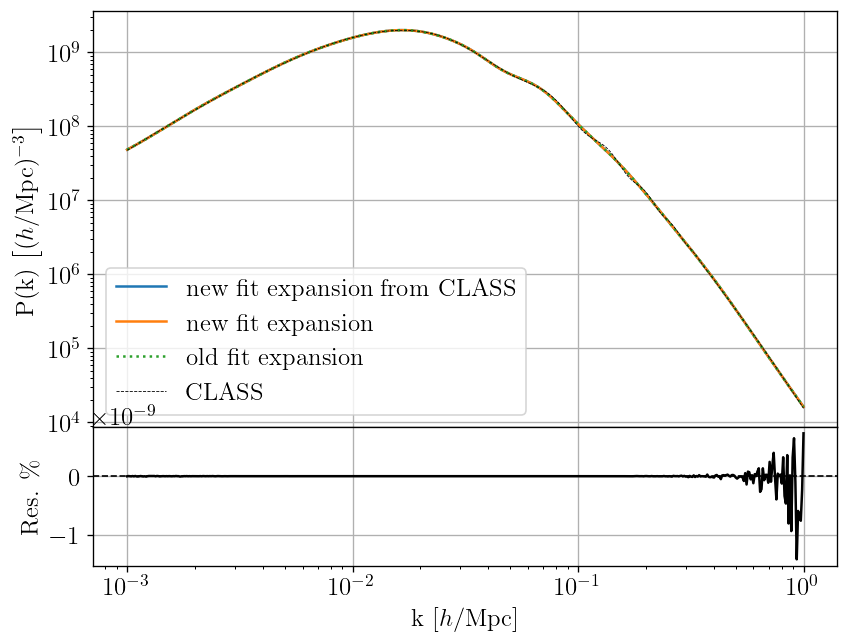

In [ ]:
alpha_text = ["a0", "a1", "a2", "a3", "b0", "b1", "b2", "b3", "c0", "c1", "c2", "c3", "d0", "d1", "d2", "d3"]
n_idx = np.array([0, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 3, 3, 4, 4, 4, 4])
i_idx = np.array([0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0])
m_idx = np.array([1, 1, 2, 3, 1, 2, 3, 4, 1, 2, 3, 4, 5, 1, 2, 3, 4])


d_idx = m_idx-i_idx

def abs_sq(q):
    return np.sum(q**2, axis=-1)

def alpha_tilde(alpha):
    coeffs = np.zeros(17, dtype=complex)
    # alpha_tilde_0:
    coeffs[0] = alpha[0]/2. * k2_UV_n[0] # factor 1/2 since in the end we have temp + np.conj(temp). Since the first term is real, we have to account for that

    # alpha_tilde_1, 2, 3:
    x=0
    for i in range(1, 4):
        dm = i
        #print("")
        #print(f"l goes from: {i} to 3")
        for l in range(i,4):
            idx = l
            j = l
            coeffs[i] += alpha[idx] * kappa_j_m(j, i) * k2_UV_n[1]**i
            #print(f"kappa_j_m({j}, {i}) = { kappa_j_m(j, i)}")

    # alpha_tilde_4, 5, 6, 7:
    x = 1
    for i in range(0, 4):
        dm = i
        for l in range(dm, 4):
            idx = 4+l
            j = x+l
            coeffs[i+4] += alpha[idx] * kappa_j_m(j, i+1) * k2_UV_n[2]**i
    
    # alpha_tilde_8, 9, 10, 11, 12:
    x = 2
    for i in range(0, 5):
        m = 1+i
        if m<=x:
            dm=0
        else:
            dm=m-x
        for l in range(dm, 4):
            idx = 8+l
            j = x+l
            coeffs[i+8] += alpha[idx] * kappa_j_m(j, i+1) * k2_UV_n[3]**(i+1)

    # alpha_tilde_13, 14, 15, 16:
    x = 1
    for i in range(0, 4):
        dm=i
        for l in range(dm, 4):
            idx = 12+l
            j = x+l
            coeffs[i+13] += alpha[idx] * kappa_j(j)[i]* k2_UV_n[4]**(i+1)
    
    return coeffs

alpha_tilde_n = alpha_tilde(alpha_n)
N_fit = 100

C_d = LambdaCDM.get_pfit_massive_propagator(k_size, k_min, k_max, z[0])


#for i in range(17):
#    print(f"CLASS: {C_d[i]}, Python: {alpha_tilde_n[i]}")



Mn = -k2_peak_n + 1j* k2_UV_n
Mn[0] = k2_UV_n[0]

k_vec = np.zeros((k_size, 3))

k_vec[:, 0] = k

# matrix for one power spectrum -> later M() is the matrix for the product of 3 power spectra
def M_one(idx1, k1, M1):

    i1 = i_idx[idx1]
    d1 = m_idx[idx1]
    # print(f"idx={idx}, idx_exp_k = {i1}, idx_exp_prop = {d1}, M1 = {M1}")
    return abs_sq(k1)**i1 / (abs_sq(k1) + M1)**d1


Pk_fit_supernew = np.zeros(k_size, dtype=complex)
temp = np.zeros(k_size, dtype=complex)
for idx in range(17):
    #temp = alpha_tilde_n[idx] * M_one(idx, k_vec, Mn[n_idx[idx]])
    temp = C_d[idx] * M_one(idx, k_vec, Mn[n_idx[idx]])
    #print(f"idx {idx}: tmp = {temp[0]}")
    Pk_fit_supernew += temp + np.conj(temp)

P_fit_CLASS = np.zeros(k_size)

for i, k_in in enumerate(k):
    if (100*(i+1)/k_size)%10==0:
        print(f"{100*(i+1)/k_size}%")
    P_fit_CLASS[i] = LambdaCDM.get_B321_real(k_size, k_min, k_max, k_in, k_in, k_in, z[0])

#residuals = 100*(1-Pk_fit/Pk_fit_supernew)
residuals = 100*(1- P_fit_CLASS/(Pk_fit_supernew*Pk_fit_supernew) )


fig = plt.figure(figsize=(8, 6))
gs = GridSpec(2, 1, height_ratios=[3, 1], hspace=0)

# Main plot (data + fit)
ax1 = fig.add_subplot(gs[0])
ax1.plot(k/h, np.abs(P_fit_CLASS)*h**3, linewidth=1.5, label="new fit expansion from CLASS")
ax1.plot(k/h, np.abs(Pk_fit_supernew*Pk_fit_supernew)*h**3, linewidth=1.5, label="new fit expansion")
ax1.plot(k/h, Pk_fit*Pk_fit_supernew*h**3, linewidth=1.5, ls=":", label="old fit expansion")
ax1.plot(k/h, Pk*Pk*h**3, ls="--", color="black", linewidth=0.5, label="CLASS")
ax1.set_ylabel(rf"P(k) $\left[(h/\mathrm{{Mpc}})^{{-3}}\right]$")
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.legend()
ax1.grid()

# Residual plot (same x-axis)
ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax2.axhline(0, color='black', linestyle='--', linewidth=1)
ax2.plot(k/h, residuals, color='black', label="Residuals")
ax2.set_xlabel(rf"k $\left[h/\mathrm{{Mpc}}\right]$")
ax2.set_ylabel(r"Res. $\%$")
ax2.set_xscale("log")
ax2.grid()




# $B_{222}$ in Real Space:

$F_2(\textbf{q}_1, \textbf{q}_2) = \frac{1}{28} \left( 10 + 3 \frac{|\textbf{q}_1+\textbf{q}_2|^2}{q_1^2} + 3 \frac{|\textbf{q}_1+\textbf{q}_2|^2}{q_2^2} - 5 \frac{q_1^2}{q_2^2} - 5 \frac{q_2^2}{q_1^2} + 2 \frac{|\textbf{q}_1+\textbf{q}_2|^4}{q_2^2} \right) \equiv \sum_{i} c_i q_1^{2n_i} q_2^{2m_i} |\textbf{q}_1+\textbf{q}_2|^{-2(n_i+m_i)}$

$\bar{B}_{222} = 8 \int_\textbf{q} F_2(\textbf{q}, \textbf{k}_1 - \textbf{q}) F_2(\textbf{k}_1 - \textbf{q}, \textbf{k}_2 + \textbf{q}) F_2(\textbf{k}_2+\textbf{q}, -\textbf{q})\ P_{fit}(q) P_{fit}(|\textbf{k}_1-\textbf{q}|) P_{fit}(|\textbf{k}_2+\textbf{q}|)$

## Step 2: Expand the Kernel $F_2$
$F_2(\textbf{q}, \textbf{k}_1 - \textbf{q}) F_2(\textbf{k}_1 - \textbf{q}, \textbf{k}_2 + \textbf{q}) F_2(\textbf{k}_2+\textbf{q}, -\textbf{q}) 
= \sum_{(i_1, i_2, i_3)} c_{i_1} c_{i_2} c_{i_3}\quad |\textbf{k}_1-\textbf{q}|^{2a_i}\ q^{2b_i}\ |\textbf{k}_2+\textbf{q}|^{2c_i}\quad    k_1^{-2d_i} k_3^{-2e_i} k_2^{-2f_i} $

$a_i = m_{i_1} + n_{i_2}$

$b_i = m_{i_3} + n_{i_1}$

$c_i = m_{i_2} + n_{i_3}$

$d_i = m_{i_1} + n_{i_1}$

$e_i = m_{i_2} + n_{i_2}$

$f_i = m_{i_3} + n_{i_3}$

number of iterations: 4913


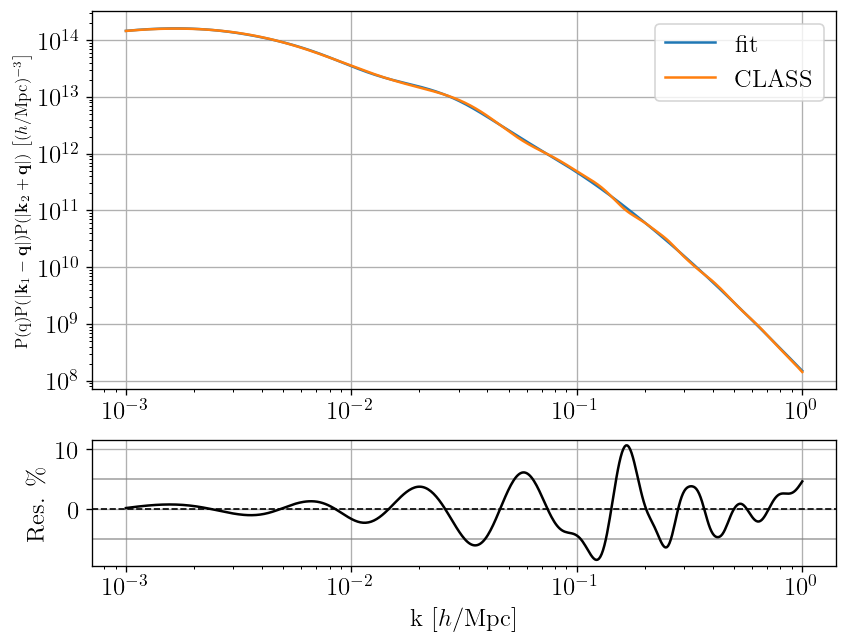

In [10]:
# Just as a reminder:
k2_peak_n = np.array([0, -3.4e-2, -1e-3, -7.6e-5, -1.56e-5])*h**2
k2_UV_n = np.array([1e-4, 6.9e-2, 8.2e-3, 1.3e-3, 1.35e-5])*h**2
i_n = np.array([0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0])
j_n = np.array([1, 1, 2, 3, 1, 2, 3, 4, 2, 3, 4, 5, 1, 2, 3, 4])

n_idx = np.array([0, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 3, 3, 4, 4, 4, 4])
i_idx = np.array([0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0])
m_idx = np.array([1, 1, 2, 3, 1, 2, 3, 4, 1, 2, 3, 4, 5, 1, 2, 3, 4])

c_i = np.array([10, 3, 3, -5, -5 , 2])/28
m_i = np.array([0, 0, -1, -1, 1 , -1])
n_i = np.array([0, -1, 0, 1, -1 , -1])



def contribution(q1, q2, m_i, n_i):
    return  abs_sq(q2)**m_i * abs_sq(q1)**n_i * abs_sq(q1+q2)**(-m_i-n_i)

def contr(q, k1, k2, a, b, c, d, e, f):
    k3 = -k1-k2
    return abs_sq(k1-q)**a * abs_sq(q)**b * abs_sq(k2+q)**c * abs_sq(k1)**(-d) * abs_sq(k3)**(-e) * abs_sq(k2)**(-f)

def F_2(q1, q2):
    terms = 10 + 3* abs_sq(q1+q2)/abs_sq(q1) + 3* abs_sq(q1+q2)/abs_sq(q2) - 5* abs_sq(q1)/abs_sq(q2) - 5* abs_sq(q2)/abs_sq(q1) + 2* abs_sq(q1+q2)**2/( abs_sq(q1)*abs_sq(q2))
    return terms/28

def v_basis(q1, q2):
    return np.array([1, abs_sq(q1+q2)/abs_sq(q1), abs_sq(q1+q2)/abs_sq(q2), abs_sq(q1)/abs_sq(q2), abs_sq(q2)/abs_sq(q1), abs_sq(q1+q2)**2/( abs_sq(q1)*abs_sq(q2) )], dtype=float)



# -------------------------------------------- Step 1: Expand Power spectrum --------------------------------------------
def M(idx1, idx2, idx3, k1, k2, k3, M1, M2, M3):
    i1 = i_idx[idx1]
    d1 = m_idx[idx1]

    i2 = i_idx[idx2]
    d2 = m_idx[idx2]
    
    i3 = i_idx[idx3]
    d3 = m_idx[idx3]
    return abs_sq(k1)**i1 / (abs_sq(k1) + M1)**d1   *   abs_sq(k2)**i2 / (abs_sq(k2) + M2)**d2    *   abs_sq(k3)**i3 / (abs_sq(k3) + M3)**d3



k1_vec = np.zeros((k_size, 3))
k2_vec = np.zeros((k_size, 3))
q_vec = np.zeros((k_size, 3))

k1_vec[:, 0] = k/10.
k2_vec[:, 1] = k
k3_vec = -k1_vec -k2_vec
q_vec[:, 2] = np.sqrt(k)/3.

Pk_fit_3 = np.zeros(k_size, dtype=complex)
tmp = np.zeros(k_size, dtype=complex)


count=0
for idx1 in range(17):
    for idx2 in range(17):
        for idx3 in range(17):
            count += 1

            M1 = Mn[n_idx[idx1]]
            M2 = Mn[n_idx[idx2]]
            M3 = Mn[n_idx[idx3]]

            M2_c = np.conj(M2)
            M3_c = np.conj(M3)

            term1 = alpha_tilde_n[idx1] * alpha_tilde_n[idx2]           * alpha_tilde_n[idx3]           * M(idx1, idx2, idx3, q_vec, k1_vec-q_vec, k2_vec+q_vec, M1, M2, M3)
            term2 = alpha_tilde_n[idx1] * alpha_tilde_n[idx2]           * np.conj(alpha_tilde_n[idx3])  * M(idx1, idx2, idx3, q_vec, k1_vec-q_vec, k2_vec+q_vec, M1, M2, M3_c)
            term3 = alpha_tilde_n[idx1] * np.conj(alpha_tilde_n[idx2])  * alpha_tilde_n[idx3]           * M(idx1, idx2, idx3, q_vec, k1_vec-q_vec, k2_vec+q_vec, M1, M2_c, M3)
            term4 = alpha_tilde_n[idx1] * np.conj(alpha_tilde_n[idx2])  * np.conj(alpha_tilde_n[idx3])  * M(idx1, idx2, idx3, q_vec, k1_vec-q_vec, k2_vec+q_vec, M1, M2_c, M3_c)

            tmp = term1 + term2 + term3 + term4
    
            Pk_fit_3 += tmp + np.conjugate(tmp)
print("number of iterations:", count)

Pk_1 = LambdaCDM.get_pk_lin(np.sqrt(abs_sq(q_vec)).reshape((k_size, z_size, mu_size)), z, k_size, z_size, mu_size)[:,0,0]
Pk_2 = LambdaCDM.get_pk_lin(np.sqrt(abs_sq(k1_vec-q_vec)).reshape((k_size, z_size, mu_size)), z, k_size, z_size, mu_size)[:,0,0]
Pk_3 = LambdaCDM.get_pk_lin(np.sqrt(abs_sq(k2_vec+q_vec)).reshape((k_size, z_size, mu_size)), z, k_size, z_size, mu_size)[:,0,0]




Pk_Pk_Pk = Pk_1*Pk_2*Pk_3
residuals = 100*(1 - Pk_Pk_Pk/Pk_fit_3)


fig = plt.figure(figsize=(8, 6))
gs = GridSpec(2, 1, height_ratios=[3, 1], hspace=0.2)
# Main plot (data + fit)
ax1 = fig.add_subplot(gs[0])
ax1.plot(k/h, Pk_fit_3*h**3, label="fit")
ax1.plot(k/h, Pk_Pk_Pk*h**3, label="CLASS")
ax1.set_ylabel(rf"P(q)P($|\textbf{{k}}_1-\textbf{{q}}|$)P($|\textbf{{k}}_2+\textbf{{q}}|$) $\left[(h/\mathrm{{Mpc}})^{{-3}}\right]$", fontsize=10)
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.legend()
ax1.grid()

# Residual plot (same x-axis)
ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax2.axhline(0, color='black', linestyle='--', linewidth=1)
ax2.axhline(-5, color='grey', alpha=0.7, linewidth=1)
ax2.axhline(5, color='grey', alpha=0.7, linewidth=1)
ax2.plot(k/h, residuals, color='black', label="Residuals")
#ax2.set_ylim(-7, 7)
ax2.set_xlabel(rf"k $\left[h/\mathrm{{Mpc}}\right]$")
ax2.set_ylabel(r"Res. $\%$")
ax2.set_xscale("log")
ax2.grid()


In [11]:
def clean_mathematica_number(s):
    return float(s[:-4])  # Remove first char (") and last 4 chars (`15.")



# -------------------------------------------- Step 2: Expand the Kernels --------------------------------------------
F2_1 = F_2(q_vec, k1_vec-q_vec)
F2_2 = F_2(k1_vec-q_vec, k2_vec+q_vec)
F2_3 = F_2(k2_vec+q_vec, -q_vec)

F2F2F2 = 0
count = 0
for idx1, ci1 in enumerate(c_i):
    for idx2, ci2 in enumerate(c_i):
        for idx3, ci3 in enumerate(c_i):
            count += 1
            a = m_i[idx1] + n_i[idx2]
            b = m_i[idx3] + n_i[idx1]
            c = m_i[idx2] + n_i[idx3]

            d = m_i[idx1] + n_i[idx1]
            e = m_i[idx2] + n_i[idx2]
            f = m_i[idx3] + n_i[idx3]
            F2F2F2 += ci1*ci2*ci3 * contr(q_vec, k1_vec, k2_vec, a, b, c, d, e, f)
print("number of iterations:", count)

dir = '/Users/fynn/Desktop/Uni/Master/Masters-thesis/04 Mathematica/0 Kernels'
F2F2F2_mathematica = 0
count_m = 0
F2F2F2_exps_mathematica = np.array(pd.read_csv(dir+"/f2f2f2new_real_exps.csv", names=["k12", "k22", "k32", "q2", "k1mq2", "k2pq2"]))
F2F2F2_coeffs_mathematica = np.array(pd.read_csv(dir+"/f2f2f2new_real_coeffs.csv", names = ["coeff"]))

coeffs = F2F2F2_coeffs_mathematica[:,0]
exp_k12 = F2F2F2_exps_mathematica[:,0]
exp_k22 = F2F2F2_exps_mathematica[:,1]
exp_k32 = F2F2F2_exps_mathematica[:,2]
exp_q2 = F2F2F2_exps_mathematica[:,3]
exp_k1mq2 = F2F2F2_exps_mathematica[:,4]
exp_k2pq2 = F2F2F2_exps_mathematica[:,5]



len_F2F2F2 = len(F2F2F2_exps_mathematica)

k12 = abs_sq(k1_vec)
k22 = abs_sq(k2_vec)
k32 = abs_sq(- k1_vec - k2_vec)
q2  = abs_sq(q_vec)
k1mq2  = abs_sq(k1_vec - q_vec)
k2pq2  = abs_sq(k2_vec + q_vec)
for i in range(len_F2F2F2):
    F2F2F2_mathematica += clean_mathematica_number(coeffs[i]) * k12**exp_k12[i] * k22**exp_k22[i] * k32**exp_k32[i] * q2**exp_q2[i] * k1mq2**exp_k1mq2[i] * k2pq2**exp_k2pq2[i]

def compare_F2F2F2(x, y1, y2, label_y1, label_y2):
    res = 1 - y1/y2

    fig = plt.figure(figsize=(8, 6))
    gs = GridSpec(2, 1, height_ratios=[3, 1], hspace=0.2)

    ax1 = fig.add_subplot(gs[0])
    ax1.plot(x, y1, label=label_y1)
    ax1.plot(x, y2, label=label_y2)
    ax1.set_ylabel(rf"$F_2 F_2 F_2$")
    ax1.set_yscale("log")
    ax1.legend()
    ax1.grid()

    # Residual plot (same x-axis)
    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    ax2.axhline(0, color='black', linestyle='--', linewidth=1)
    ax2.plot(x, res, color='black', label="Residuals")
    ax2.set_xlabel(rf"k $\left[h/\mathrm{{Mpc}}\right]$")
    ax2.set_ylabel(r"Res. $\%$")
    ax2.set_xscale("log")
    ax2.grid()

compare_F2F2F2(k/h, F2F2F2_mathematica, F2_1*F2_2*F2_3, "Expansion Mathematica", "Explicit Product")
compare_F2F2F2(k/h, F2F2F2_mathematica, F2F2F2, "Expansion Mathematica", "Explicit Expansion")
compare_F2F2F2(k/h, F2_1*F2_2*F2_3, F2F2F2, "Explicit Product", "Explicit Expansion")


number of iterations: 216


FileNotFoundError: [Errno 2] No such file or directory: '/Users/fynn/Desktop/Uni/Master/Masters-thesis/04 Mathematica/0 Kernels/f2f2f2new_real_exps.csv'

In [ ]:
# -------------------------------------------- Step 3: Expand B_222 --------------------------------------------
def L(i1, i2, i3, idx1, idx2, idx3, k1, k2, k3, M1, M2, M3):
    """
    m1, m2, m3, d1, d2, d3: idices for power spectrum expansion
    idx1, idx2, idx3: indices for kernel expansion
    """
    a = m_i[idx1] + n_i[idx2]
    b = m_i[idx3] + n_i[idx1]
    c = m_i[idx2] + n_i[idx3]

    d = m_i[idx1] + n_i[idx1]
    e = m_i[idx2] + n_i[idx2]
    f = m_i[idx3] + n_i[idx3]

    # kernels*Pks is the integrant, so this will be replaced by the solution of the integral
    kernels = contr(q_vec, k1_vec, k2_vec, a, b, c, d, e, f)

    return kernels * M(i1, i2, i3, k1, k2, k3, M1, M2, M3)


l1 = len(c_i)
l2 = 17

l_tot = l1**3 * l2**3
L_111 = np.zeros((l_tot, k_size), dtype=complex)
L_11c = np.zeros((l_tot, k_size), dtype=complex)
L_1c1 = np.zeros((l_tot, k_size), dtype=complex)
L_1cc = np.zeros((l_tot, k_size), dtype=complex)


print(l_tot)
count = 0

for idx1, ci1 in enumerate(c_i):
    print(f"step: {idx1}")
    for idx2, ci2 in enumerate(c_i):
        for idx3, ci3 in enumerate(c_i):
            C_123 = ci1*ci2*ci3
            for i1 in range(l2):
                for i2 in range(l2):
                    for i3 in range(l2):

                        M1 = Mn[n_idx[i1]]
                        M2 = Mn[n_idx[i2]]
                        M3 = Mn[n_idx[i3]]

                        M2_c = np.conj(M2)
                        M3_c = np.conj(M3)

                        idx_tot = i3 + l2*i2 + l2**2*i1 + l2**3 *idx3 + l1*l2**3 *idx2 + l1**2*l2**3 *idx1

                        L_111[idx_tot,:] = L(i1, i2, i3, idx1, idx2, idx3, q_vec, k1_vec-q_vec, k2_vec+q_vec, M1, M2, M3)
                        L_11c[idx_tot,:] = L(i1, i2, i3, idx1, idx2, idx3, q_vec, k1_vec-q_vec, k2_vec+q_vec, M1, M2, M3_c)
                        L_1c1[idx_tot,:] = L(i1, i2, i3, idx1, idx2, idx3, q_vec, k1_vec-q_vec, k2_vec+q_vec, M1, M2_c, M3)
                        L_1cc[idx_tot,:] = L(i1, i2, i3, idx1, idx2, idx3, q_vec, k1_vec-q_vec, k2_vec+q_vec, M1, M2_c, M3_c)


1061208
step: 0
step: 1
step: 2
step: 3
step: 4
step: 5


0
1
2
3
4
5
number of iterations: 0


/Users/fynn/miniforge3/envs/class-env-1/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/fynn/miniforge3/envs/class-env-1/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


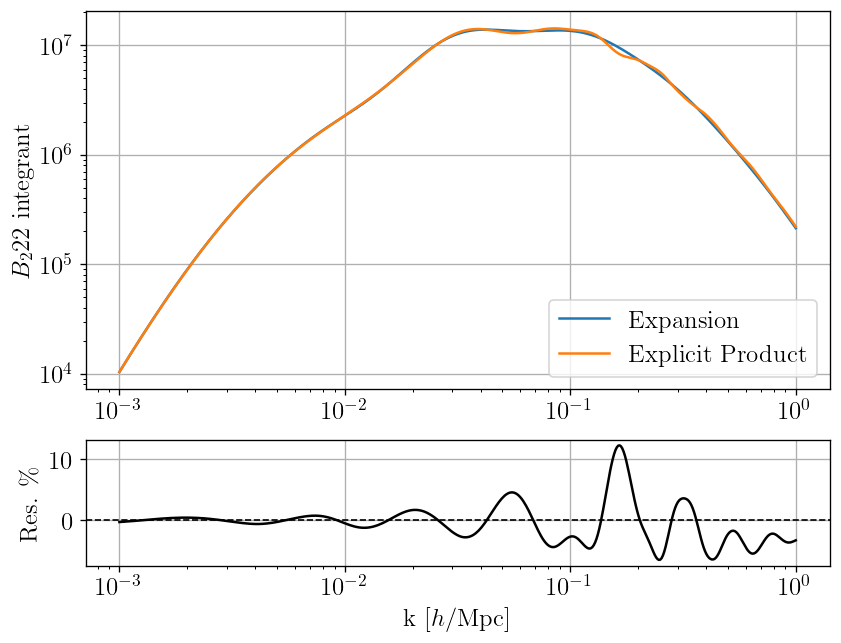

In [ ]:



B_222_integrant = np.zeros(k_size, dtype=complex)
tmp = np.zeros(k_size, dtype=complex)

count=0
for idx1, ci1 in enumerate(c_i):
    print(idx1)
    for idx2, ci2 in enumerate(c_i):
        for idx3, ci3 in enumerate(c_i):
            C_123 = ci1*ci2*ci3

            for i1 in range(17):
                for i2 in range(17):
                    for i3 in range(17):
                        idx_tot = i3 + l2*i2 + l2**2*i1 + l2**3 *idx3 + l1*l2**3 *idx2 + l1**2*l2**3 *idx1

                        term1 = alpha_tilde_n[i1] * alpha_tilde_n[i2]           * alpha_tilde_n[i3]           * L_111[idx_tot,:]
                        term2 = alpha_tilde_n[i1] * alpha_tilde_n[i2]           * np.conj(alpha_tilde_n[i3])  * L_11c[idx_tot,:]
                        term3 = alpha_tilde_n[i1] * np.conj(alpha_tilde_n[i2])  * alpha_tilde_n[i3]           * L_1c1[idx_tot,:]
                        term4 = alpha_tilde_n[i1] * np.conj(alpha_tilde_n[i2])  * np.conj(alpha_tilde_n[i3])  * L_1cc[idx_tot,:]

                        tmp = C_123*(term1 + term2 + term3 + term4)
                
                        B_222_integrant += tmp + np.conjugate(tmp)

print("number of iterations:", count)


B_222_integrant_explicit = F2_1*F2_2*F2_3 * Pk_1*Pk_2*Pk_3

residuals = 100*(1 - B_222_integrant_explicit/B_222_integrant)

fig = plt.figure(figsize=(8, 6))
gs = GridSpec(2, 1, height_ratios=[3, 1], hspace=0.2)
# Main plot (data + fit)
ax1 = fig.add_subplot(gs[0])
ax1.plot(k/h, B_222_integrant, label="Expansion")
ax1.plot(k/h, B_222_integrant_explicit, label="Explicit Product")
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_ylabel(rf"$B_{222}$ integrant")
ax1.legend()
ax1.grid()

# Residual plot (same x-axis)
ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax2.axhline(0, color='black', linestyle='--', linewidth=1)
ax2.plot(k/h, residuals, color='black', label="Residuals")
ax2.set_xlabel(rf"k $\left[h/\mathrm{{Mpc}}\right]$")
ax2.set_ylabel(r"Res. $\%$")
ax2.set_xscale("log")
ax2.grid()

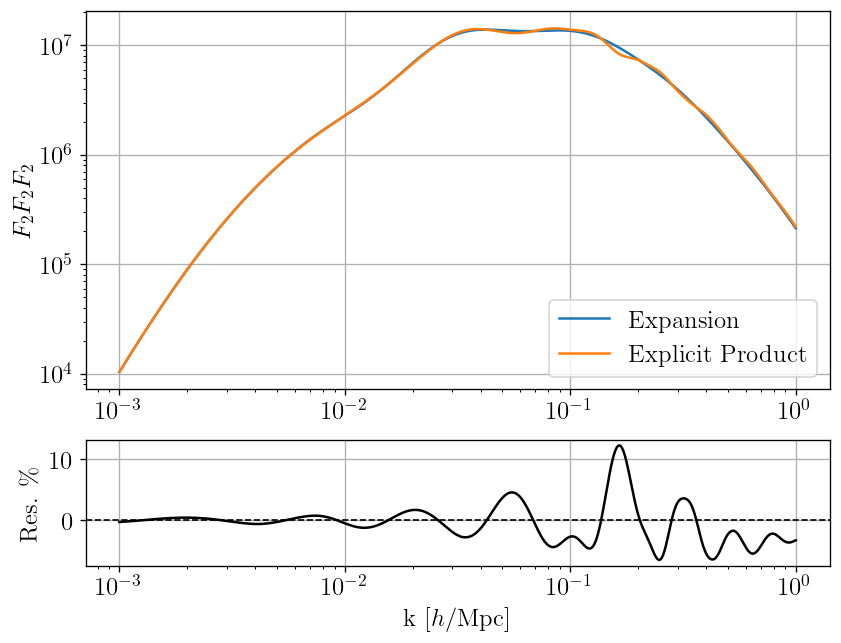

In [ ]:
fig = plt.figure(figsize=(8, 6))
gs = GridSpec(2, 1, height_ratios=[3, 1], hspace=0.2)
# Main plot (data + fit)
ax1 = fig.add_subplot(gs[0])
ax1.plot(k/h, B_222_integrant, label="Expansion")
ax1.plot(k/h, B_222_integrant_explicit, label="Explicit Product")
#ax1.plot(k/h, F2_1, label="Explicit Product")
#ax1.plot(k/h, F2_2, label="Explicit Product")
#ax1.plot(k/h, F2_3, label="Explicit Product")
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_ylabel(rf"$F_2 F_2 F_2$")
ax1.legend()
ax1.grid()

# Residual plot (same x-axis)
ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax2.axhline(0, color='black', linestyle='--', linewidth=1)
ax2.plot(k/h, residuals, color='black', label="Residuals")
ax2.set_xlabel(rf"k $\left[h/\mathrm{{Mpc}}\right]$")
ax2.set_ylabel(r"Res. $\%$")
ax2.set_xscale("log")
ax2.grid()